In [ ]:
# ------------
# txt_to_geojsons
import os
import json
from pathlib import Path
from PIL import Image
import uuid
import cv2

# =========================
# CONFIG
# =========================

YOLO_LABEL_DIR = r"/home/khushi/Pixonate/New_Anemia/R_new_anemia/model_outputs/color_box_outputs/Finetune_data/labels"      # folder containing YOLO txt files
IMAGE_DIR = r"/home/khushi/Pixonate/New_Anemia/R_new_anemia/model_outputs/color_box_outputs/Finetune_data/images"         # folder containing corresponding images
OUTPUT_DIR = r"/home/khushi/Pixonate/New_Anemia/R_new_anemia/model_outputs/color_box_outputs/Finetune_data/geojson"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# =========================
# UTILS
# =========================

def yolo_to_polygon(xc, yc, w, h, img_w, img_h):
    """
    Convert YOLO normalized bbox to polygon (pixel coords)
    """
    x_center = xc * img_w
    y_center = yc * img_h
    bw = w * img_w
    bh = h * img_h

    x1 = int(x_center - bw / 2)
    y1 = int(y_center - bh / 2)
    x2 = int(x_center + bw / 2)
    y2 = int(y_center + bh / 2)

    # Closed polygon
    return [
        [x1, y1],
        [x1, y2],
        [x2, y2],
        [x2, y1],
        [x1, y1]
    ]

# =========================
# MAIN CONVERSION
# =========================

for label_file in sorted(os.listdir(YOLO_LABEL_DIR)):
    if not label_file.endswith(".txt"):
        continue

    name = os.path.splitext(label_file)[0]
    img_path = None

    # find corresponding image
    for ext in [".jpg", ".jpeg", ".png"]:
        candidate = os.path.join(IMAGE_DIR, name + ext)
        if os.path.exists(candidate):
            img_path = candidate
            break

    if img_path is None:
        print(f"⚠️ Image not found for {label_file}")
        continue

    img = cv2.imread(img_path)
    img_h, img_w = img.shape[:2]

    features = []

    with open(os.path.join(YOLO_LABEL_DIR, label_file)) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:
                continue

            cls, xc, yc, w, h = map(float, parts)

            polygon = yolo_to_polygon(xc, yc, w, h, img_w, img_h)

            feature = {
                "type": "Feature",
                "id": str(uuid.uuid4()),
                "geometry": {
                    "type": "Polygon",
                    "coordinates": [polygon]
                },
                "properties": {
                    "objectType": "annotation"
                }
            }

            features.append(feature)

    geojson = {
        "type": "FeatureCollection",
        "features": features
    }

    out_path = os.path.join(OUTPUT_DIR, f"{name}.geojson")
    with open(out_path, "w") as f:
        json.dump(geojson, f, indent=2)

print("✅ YOLO → GeoJSON conversion completed")


In [1]:
#masks_to_geojsons
import os
import cv2
import json
import uuid

# =========================
# CONFIG
# =========================
MASK_DIR   = "/home/khushi/Pixonate/New_Anemia/R_new_anemia/model_outputs/seg_outputs1/Finetune_data/Data/seg_1/masks"
OUTPUT_DIR = "/home/khushi/Pixonate/New_Anemia/R_new_anemia/model_outputs/seg_outputs1/Finetune_data/Data/seg_1/geojsons"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# =========================
# MAIN
# =========================

for mask_name in sorted(os.listdir(MASK_DIR)):
    if not mask_name.lower().endswith((".png", ".jpg", ".jpeg")):
        continue

    mask_path = os.path.join(MASK_DIR, mask_name)
    name = os.path.splitext(mask_name)[0]

    # Load mask
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        continue

    # Ensure binary
    _, mask_bin = cv2.threshold(mask, 1, 255, cv2.THRESH_BINARY)

    # Find contours (pixel-accurate)
    contours, _ = cv2.findContours(
        mask_bin,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_NONE  # <-- keeps dense points like your example
    )

    features = []

    for cnt in contours:
        if len(cnt) < 3:
            continue

        # Convert contour to [[x, y], ...]
        polygon = [[int(pt[0][0]), int(pt[0][1])] for pt in cnt]

        # Close polygon if not closed
        if polygon[0] != polygon[-1]:
            polygon.append(polygon[0])

        feature = {
            "type": "Feature",
            "id": str(uuid.uuid4()),
            "geometry": {
                "type": "Polygon",
                "coordinates": [polygon]
            },
            "properties": {
                "objectType": "annotation"
            }
        }

        features.append(feature)

    geojson = {
        "type": "FeatureCollection",
        "features": features
    }

    out_path = os.path.join(OUTPUT_DIR, f"{name}.geojson")
    with open(out_path, "w") as f:
        json.dump(geojson, f, indent=2)

print("✅ Mask → GeoJSON conversion completed")


✅ Mask → GeoJSON conversion completed


In [33]:
# geojsons_to_txt
import os
import json
import cv2

# =========================
# CONFIG
# =========================
GEOJSON_DIR = "/home/khushi/Pixonate/New_Anemia/R_new_anemia/model_outputs/eye_outputs/Finetune_data/CV_images/cv2_qu/geojsons"
IMAGE_DIR   = "/home/khushi/Pixonate/New_Anemia/R_new_anemia/model_outputs/eye_outputs/Finetune_data/CV_images"
OUTPUT_DIR  = "/home/khushi/Pixonate/New_Anemia/R_new_anemia/model_outputs/eye_outputs/Finetune_data/CV_images/cv2_qu/labels"

CLASS_ID = 0  # change if needed

os.makedirs(OUTPUT_DIR, exist_ok=True)

# =========================
# UTILS
# =========================

def polygon_to_yolo(polygon, img_w, img_h):
    xs = [p[0] for p in polygon]
    ys = [p[1] for p in polygon]

    x_min, x_max = min(xs), max(xs)
    y_min, y_max = min(ys), max(ys)

    x_center = ((x_min + x_max) / 2) / img_w
    y_center = ((y_min + y_max) / 2) / img_h
    width  = (x_max - x_min) / img_w
    height = (y_max - y_min) / img_h

    return x_center, y_center, width, height

# =========================
# MAIN
# =========================

for geo_name in sorted(os.listdir(GEOJSON_DIR)):
    if not geo_name.endswith(".geojson"):
        continue

    name = os.path.splitext(geo_name)[0]

    # find matching image
    img_path = None
    for ext in [".jpg", ".jpeg", ".png"]:
        p = os.path.join(IMAGE_DIR, name + ext)
        if os.path.exists(p):
            img_path = p
            break

    if img_path is None:
        print(f"⚠️ Image not found for {geo_name}")
        continue

    img = cv2.imread(img_path)
    img_w, img_h = img.shape[:2]

    with open(os.path.join(GEOJSON_DIR, geo_name)) as f:
        data = json.load(f)

    yolo_lines = []

    for feature in data.get("features", []):
        geom = feature.get("geometry", {})
        if geom.get("type") != "Polygon":
            continue

        polygon = geom["coordinates"][0]

        x, y, w, h = polygon_to_yolo(polygon, img_w, img_h)

        yolo_lines.append(
            f"{CLASS_ID} {x:.6f} {y:.6f} {w:.6f} {h:.6f}"
        )

    # write YOLO txt
    out_txt = os.path.join(OUTPUT_DIR, f"{name}.txt")
    with open(out_txt, "w") as f:
        f.write("\n".join(yolo_lines))

print("✅ GeoJSON → YOLO conversion completed")


✅ GeoJSON → YOLO conversion completed


In [34]:
#Overlay_txt_files
import os
import cv2

# =========================
# CONFIG
# =========================
IMAGE_DIR   = "/home/khushi/Pixonate/New_Anemia/R_new_anemia/model_outputs/eye_outputs/Finetune_data/CV_images"
LABEL_DIR   = "/home/khushi/Pixonate/New_Anemia/R_new_anemia/model_outputs/eye_outputs/Finetune_data/CV_images/cv2_qu/labels"
OUTPUT_DIR  = "/home/khushi/Pixonate/New_Anemia/R_new_anemia/model_outputs/eye_outputs/Finetune_data/CV_images/cv2_qu/lastoverlay"

BOX_COLOR   = (0, 255, 0)  # Green
TEXT_COLOR  = (0, 255, 0)
THICKNESS   = 2
FONT_SCALE  = 0.6

os.makedirs(OUTPUT_DIR, exist_ok=True)

# =========================
# MAIN
# =========================

for img_name in sorted(os.listdir(IMAGE_DIR)):
    if not img_name.lower().endswith((".jpg", ".jpeg", ".png")):
        continue

    name = os.path.splitext(img_name)[0]
    img_path = os.path.join(IMAGE_DIR, img_name)
    txt_path = os.path.join(LABEL_DIR, name + ".txt")

    if not os.path.exists(txt_path):
        continue

    img = cv2.imread(img_path)
    h, w = img.shape[:2]

    with open(txt_path) as f:
        for line in f:
            cls, xc, yc, bw, bh = map(float, line.strip().split())

            # Convert YOLO → pixel coords
            x_center = xc * w
            y_center = yc * h
            box_w = bw * w
            box_h = bh * h

            x1 = int(x_center - box_w / 2)
            y1 = int(y_center - box_h / 2)
            x2 = int(x_center + box_w / 2)
            y2 = int(y_center + box_h / 2)

            # Draw box
            cv2.rectangle(img, (x1, y1), (x2, y2), BOX_COLOR, THICKNESS)

            # Draw class id
            cv2.putText(
                img,
                f"ID:{int(cls)}",
                (x1, max(0, y1 - 5)),
                cv2.FONT_HERSHEY_SIMPLEX,
                FONT_SCALE,
                TEXT_COLOR,
                2
            )

    out_path = os.path.join(OUTPUT_DIR, img_name)
    cv2.imwrite(out_path, img)

print("✅ YOLO TXT overlay completed")


✅ YOLO TXT overlay completed


In [19]:
import matplotlib.pyplot as plt
img = cv2.imread("/home/khushi/Pixonate/New_Anemia/R_new_anemia/model_outputs/eye_outputs/Finetune_data/Eye_finetune/lo/1526.11.5.jpg")


In [20]:
img.shape

(4096, 3072, 3)

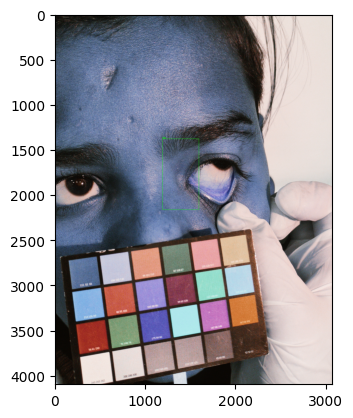

In [21]:

plt.imshow(img)

In [22]:
cv2.imwrite("sample.png", img)

True

-----------------------

------------

In [9]:
# Read_&_save_img_using_cv2
import os
import cv2

# =========================
# CONFIG
# =========================
INPUT_DIR  = "/home/khushi/Pixonate/New_Anemia/R_new_anemia/model_outputs/seg_outputs1/Finetune_data/images"
OUTPUT_DIR = "/home/khushi/Pixonate/New_Anemia/R_new_anemia/model_outputs/seg_outputs1/Finetune_data/CV_images"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# =========================
# LOOP THROUGH IMAGES
# =========================
for img_name in sorted(os.listdir(INPUT_DIR)):
    if not img_name.lower().endswith((".jpg", ".jpeg", ".png")):
        continue

    img_path = os.path.join(INPUT_DIR, img_name)
    img = cv2.imread(img_path)

    if img is None:
        continue

    out_path = os.path.join(OUTPUT_DIR, img_name)
    cv2.imwrite(out_path, img)

print("✅ All images saved to one folder")


✅ All images saved to one folder


In [3]:
# model_prediction_geojson_1
import os
import json
from ultralytics import YOLO
from pathlib import Path
import cv2

# =========================
# CONFIG
# =========================
MODEL_PATH = "/home/khushi/Pixonate/New_Anemia/Models/Finetuned model/Eye model/Fbest.pt"
INPUT_DIR = "/home/khushi/Pixonate/New_Anemia/Dec_data/DataDec-Jan/CV_504"
OUTPUT_IMG_DIR = "/home/khushi/Pixonate/New_Anemia/Dec_data/models_output/eye/pred_overlay"
OUTPUT_GEOJSON_DIR = "/home/khushi/Pixonate/New_Anemia/Dec_data/models_output/eye/pred_geojson"

IMG_EXTS = [".jpg", ".jpeg", ".png"]
CONF_THRES = 0.7

# =========================
# LOAD MODEL
# =========================
model = YOLO(MODEL_PATH)

os.makedirs(OUTPUT_IMG_DIR, exist_ok=True)
os.makedirs(OUTPUT_GEOJSON_DIR, exist_ok=True)

# =========================
# RUN PREDICTION
# =========================
for img_name in os.listdir(INPUT_DIR):
    if Path(img_name).suffix.lower() not in IMG_EXTS:
        continue

    img_path = os.path.join(INPUT_DIR, img_name)

    results = model(img_path, conf=CONF_THRES)
    r = results[0]

    # -------------------------
    # Save annotated image
    # -------------------------
    annotated_img = r.plot()
    cv2.imwrite(os.path.join(OUTPUT_IMG_DIR, img_name), annotated_img)

    # -------------------------
    # Create GeoJSON
    # -------------------------
    features = []

    if r.boxes is not None:
        for box in r.boxes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            cls_id = int(box.cls[0])
            conf = float(box.conf[0])
            class_name = model.names[cls_id]

            feature = {
                "type": "Feature",
                "properties": {
                    "class_id": cls_id,
                    "class_name": class_name,
                    "confidence": conf
                },
                "geometry": {
                    "type": "Polygon",
                    "coordinates": [[
                        [x1, y1],
                        [x2, y1],
                        [x2, y2],
                        [x1, y2],
                        [x1, y1]
                    ]]
                }
            }
            features.append(feature)

    geojson_data = {
        "type": "FeatureCollection",
        "features": features
    }

    geojson_path = os.path.join(
        OUTPUT_GEOJSON_DIR,
        Path(img_name).stem + ".geojson"
    )

    with open(geojson_path, "w") as f:
        json.dump(geojson_data, f, indent=2)

    print(f"Saved image + geojson for: {img_name}")

print("✅ Prediction + GeoJSON export completed.")



image 1/1 /home/khushi/Pixonate/New_Anemia/Dec_data/DataDec-Jan/CV_504/6954ab3f4b50e_IMG_20251229_143045442_HDR.jpg: 1024x768 1 eye, 240.7ms
Speed: 4.1ms preprocess, 240.7ms inference, 0.6ms postprocess per image at shape (1, 3, 1024, 768)
Saved image + geojson for: 6954ab3f4b50e_IMG_20251229_143045442_HDR.jpg

image 1/1 /home/khushi/Pixonate/New_Anemia/Dec_data/DataDec-Jan/CV_504/6954a8b3563e8_IMG_20251229_122011950.jpg: 1024x768 1 eye, 295.9ms
Speed: 5.5ms preprocess, 295.9ms inference, 1.0ms postprocess per image at shape (1, 3, 1024, 768)
Saved image + geojson for: 6954a8b3563e8_IMG_20251229_122011950.jpg

image 1/1 /home/khushi/Pixonate/New_Anemia/Dec_data/DataDec-Jan/CV_504/6954e1ac6afc9_IMG_20251230_122532023_HDR.jpg: 1024x768 1 eye, 239.3ms
Speed: 4.8ms preprocess, 239.3ms inference, 0.7ms postprocess per image at shape (1, 3, 1024, 768)
Saved image + geojson for: 6954e1ac6afc9_IMG_20251230_122532023_HDR.jpg

image 1/1 /home/khushi/Pixonate/New_Anemia/Dec_data/DataDec-Jan/CV_5

In [13]:
# -----------------------
# geojson_to_txt_2
#!/usr/bin/env python3
"""
geojson_to_yolo.py

Batch convert GeoJSON polygon/multipolygon annotations (in pixel coordinates)
into YOLO-format .txt files (normalized center_x center_y width height).

This version uses the USER INPUT SECTION at top — no CLI input required.
"""
import os
import json
from math import isfinite
from PIL import Image

# =============================
# USER INPUT SECTION (EDIT HERE)
# =============================
# Provide your folders directly here — no need for CLI arguments.

GEOJSON_DIR = "/home/khushi/Pixonate/New_Anemia/R_new_anemia/model_outputs/color_box_outputs/Data/All/all_color_Qu/Ogeojsons"      # folder containing .geojson files
IMAGE_DIR   = "/home/khushi/Pixonate/New_Anemia/R_new_anemia/model_outputs/color_box_outputs/Data/CV_images"        # folder containing images
OUTPUT_DIR  = "/home/khushi/Pixonate/New_Anemia/R_new_anemia/model_outputs/color_box_outputs/Data/All/Otxt"        # output YOLO txt folder
CLASS_MAP   = None             # e.g. {"nucleus": 0, "mito": 1} or path to json
CLASS_PROP  = "class"          # property name inside GeoJSON
IMAGE_PROP  = "image"          # optional image property inside GeoJSON
IMG_SIZE    = None             # e.g. (1024,768) if images not provided
EXTS        = ["png","jpg","jpeg","tif","tiff"]
DEFAULT_CLASS = 0
EPS = 1e-9
VERBOSE = True
# =============================
# END OF USER INPUT SECTION
# =============================

def parse_args():
    # return a simple args object populated from the USER INPUT SECTION
    class A: pass
    args = A()
    args.geo = None
    args.geo_dir = GEOJSON_DIR
    args.img_dir = IMAGE_DIR
    args.out = OUTPUT_DIR
    args.class_map = CLASS_MAP
    args.class_prop = CLASS_PROP
    args.image_prop = IMAGE_PROP
    args.img_size = IMG_SIZE
    args.exts = EXTS
    args.default_class = DEFAULT_CLASS
    args.eps = EPS
    args.verbose = VERBOSE
    return args

def load_geojson(path):
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)

def get_image_size_from_file(img_path):
    with Image.open(img_path) as im:
        return im.width, im.height

def polygon_bbox(coords):
    xs = [p[0] for p in coords]
    ys = [p[1] for p in coords]
    return min(xs), min(ys), max(xs), max(ys)

def extract_bboxes_from_geometry(geom):
    geoms = []
    gtype = geom.get('type')
    coords = geom.get('coordinates')
    if not coords:
        return geoms

    if gtype == 'Polygon':
        exterior = coords[0]
        geoms.append(polygon_bbox(exterior))
    elif gtype == 'MultiPolygon':
        for poly in coords:
            exterior = poly[0]
            geoms.append(polygon_bbox(exterior))
    else:
        # skip non-polygon geometries
        pass
    return geoms

def bbox_to_yolo(minx, miny, maxx, maxy, img_w, img_h, eps=1e-9):
    minx = max(0.0, minx)
    miny = max(0.0, miny)
    maxx = max(minx + eps, maxx)
    maxy = max(miny + eps, maxy)

    bx = (minx + maxx) / 2.0
    by = (miny + maxy) / 2.0
    bw = maxx - minx
    bh = maxy - miny

    nx = bx / float(img_w)
    ny = by / float(img_h)
    nw = bw / float(img_w)
    nh = bh / float(img_h)

    def clamp01(v):
        if not isfinite(v):
            return 0.0
        return min(1.0, max(0.0, v))

    return clamp01(nx), clamp01(ny), clamp01(nw), clamp01(nh)

def find_matching_image(basename, img_dir, exts):
    if not img_dir:
        return None
    for ext in exts:
        candidate = os.path.join(img_dir, f"{basename}.{ext}")
        if os.path.exists(candidate):
            return candidate
    # try case-insensitive search in directory
    try:
        files = os.listdir(img_dir)
    except Exception:
        return None
    lower = {f.lower(): f for f in files}
    for ext in exts:
        key = f"{basename}.{ext}".lower()
        if key in lower:
            return os.path.join(img_dir, lower[key])
    return None

def process_one_geo(geo_path, args, class_map):
    data = load_geojson(geo_path)
    features = data.get('features', [])
    if not features:
        if args.verbose:
            print(f"[WARN] No features in {geo_path}")
        return 0

    basename = os.path.splitext(os.path.basename(geo_path))[0]

    detections = []  # (class_id, bbox)

    for feat in features:
        props = feat.get('properties', {}) or {}
        geom = feat.get('geometry') or {}

        # class id resolution
        class_id = args.default_class
        if args.class_prop in props:
            val = props[args.class_prop]
            if class_map is not None:
                key = str(val)
                if key in class_map:
                    class_id = int(class_map[key])
                else:
                    try:
                        class_id = int(val)
                    except Exception:
                        class_id = args.default_class
            else:
                try:
                    class_id = int(val)
                except Exception:
                    class_id = args.default_class

        # extract bbox(es)
        bboxes = extract_bboxes_from_geometry(geom)
        for bbox in bboxes:
            detections.append((class_id, bbox))

    if not detections:
        if args.verbose:
            print(f"[INFO] No polygon detections in {geo_path}")
        return 0

    # determine image size
    if args.img_size:
        img_w, img_h = args.img_size
        img_path = None
    else:
        # try geo feature property 'image' first (if present)
        img_path = None
        # if any feature has the image property, use it (first one found)
        for feat in features:
            props = feat.get('properties', {}) or {}
            if args.image_prop in props:
                candidate = props[args.image_prop]
                # if full path provided, use it; else treat as basename relative to img_dir
                if os.path.isabs(candidate) and os.path.exists(candidate):
                    img_path = candidate
                    break
                else:
                    # try joining with img_dir 
                    if args.img_dir:
                        cand2 = os.path.join(args.img_dir, candidate)
                        if os.path.exists(cand2):
                            img_path = cand2
                            break
                    # if candidate looks like basename without extension, try with extensions
                    name_no_ext = os.path.splitext(candidate)[0]
                    cand3 = find_matching_image(name_no_ext, args.img_dir, args.exts)
                    if cand3:
                        img_path = cand3
                        break
        # if still not found, try matching geo basename to image basenames
        if img_path is None:
            img_path = find_matching_image(basename, args.img_dir, args.exts)

        if img_path is None:
            raise RuntimeError(f"Could not find image for '{geo_path}'. Provide img_dir or img_size or include '{args.image_prop}' property in features.")

        img_w, img_h = get_image_size_from_file(img_path)

    # write txt
    os.makedirs(args.out, exist_ok=True)
    txt_name = f"{basename}.txt"
    txt_path = os.path.join(args.out, txt_name)

    lines = []
    for class_id, (minx, miny, maxx, maxy) in detections:
        nx, ny, nw, nh = bbox_to_yolo(minx, miny, maxx, maxy, img_w, img_h, eps=args.eps)
        lines.append(f"{int(class_id)} {nx:.6f} {ny:.6f} {nw:.6f} {nh:.6f}")

    with open(txt_path, 'w', encoding='utf-8') as f:
        f.write('\n'.join(lines))

    if args.verbose:
        print(f"Wrote {len(lines)} annotations to {txt_path} (image: {img_path if 'img_path' in locals() else 'N/A'})")

    return len(lines)

def main():
    args = parse_args()

    class_map = None
    if args.class_map:
        # allow CLASS_MAP to be dict or a path string
        if isinstance(args.class_map, str) and os.path.exists(args.class_map):
            with open(args.class_map, 'r', encoding='utf-8') as f:
                class_map = json.load(f)
        else:
            class_map = args.class_map

    total = 0
    processed = 0

    if args.geo:
        processed += process_one_geo(args.geo, args, class_map) or 0
        total = 1
    else:
        # iterate directory
        geo_files = [f for f in os.listdir(args.geo_dir) if f.lower().endswith(('.geojson', '.json'))]
        if not geo_files:
            raise RuntimeError(f"No .geojson/.json files found in {args.geo_dir}")
        total = len(geo_files)
        for name in geo_files:
            geo_path = os.path.join(args.geo_dir, name)
            try:
                n = process_one_geo(geo_path, args, class_map) or 0
                processed += 1
            except Exception as e:
                print(f"[ERROR] Failed to process {geo_path}: {e}")

    print(f"Done. Processed {processed}/{total} geojson files.")

if __name__ == '__main__':
    main()

Wrote 24 annotations to /home/khushi/Pixonate/New_Anemia/R_new_anemia/model_outputs/color_box_outputs/Data/All/Otxt/1574.8.9.txt (image: /home/khushi/Pixonate/New_Anemia/R_new_anemia/model_outputs/color_box_outputs/Data/CV_images/1574.8.9.jpg)
Wrote 24 annotations to /home/khushi/Pixonate/New_Anemia/R_new_anemia/model_outputs/color_box_outputs/Data/All/Otxt/1523.8.2.txt (image: /home/khushi/Pixonate/New_Anemia/R_new_anemia/model_outputs/color_box_outputs/Data/CV_images/1523.8.2.jpg)
Wrote 24 annotations to /home/khushi/Pixonate/New_Anemia/R_new_anemia/model_outputs/color_box_outputs/Data/All/Otxt/1726.10.6.txt (image: /home/khushi/Pixonate/New_Anemia/R_new_anemia/model_outputs/color_box_outputs/Data/CV_images/1726.10.6.jpg)
Wrote 24 annotations to /home/khushi/Pixonate/New_Anemia/R_new_anemia/model_outputs/color_box_outputs/Data/All/Otxt/1567.13.1.txt (image: /home/khushi/Pixonate/New_Anemia/R_new_anemia/model_outputs/color_box_outputs/Data/CV_images/1567.13.1.jpg)
Wrote 24 annotations

In [ ]:
#overlay_goejson_3
import os
import json
import cv2
from pathlib import Path

# =========================
# CONFIG
# =========================
IMG_DIR = "/home/khushi/Pixonate/New_Anemia/R_new_anemia/model_outputs/eye_outputs/Finetune_data/CV_images/cv2_qu/N/resize_img"
GEOJSON_DIR = "/home/khushi/Pixonate/New_Anemia/R_new_anemia/model_outputs/eye_outputs/Finetune_data/CV_images/cv2_qu/geojsons"
OUTPUT_DIR = "/home/khushi/Pixonate/New_Anemia/R_new_anemia/model_outputs/eye_outputs/Finetune_data/CV_images/cv2_qu/N/res_overlay"

IMG_EXTS = [".jpg", ".jpeg", ".png"]

os.makedirs(OUTPUT_DIR, exist_ok=True)

# =========================
# DRAW GEOJSON ON IMAGE
# =========================
def draw_geojson(image, geojson_path):
    with open(geojson_path, "r") as f:
        data = json.load(f)

    for feature in data.get("features", []):
        geom = feature["geometry"]
        coords = geom["coordinates"][0]

        # convert to int pixels
        pts = [(int(x), int(y)) for x, y in coords]

        # draw polygon
        cv2.polylines(
            image,
            [np.array(pts, dtype="int32")],
            isClosed=True,
            color=(0, 255, 0),
            thickness=2
        )

        # draw label if exists
        props = feature.get("properties", {})
        label = props.get("class_name", "")

        if label:
            x, y = pts[0]
            cv2.putText(
                image,
                label,
                (x, y - 5),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (0, 255, 0),
                2
            )

    return image

# =========================
# MAIN LOOP
# =========================
import numpy as np

for img_name in os.listdir(IMG_DIR):
    if Path(img_name).suffix.lower() not in IMG_EXTS:
        continue

    img_path = os.path.join(IMG_DIR, img_name)
    geojson_path = os.path.join(
        GEOJSON_DIR, Path(img_name).stem + ".geojson"
    )

    if not os.path.exists(geojson_path):
        print(f"⚠️ GeoJSON missing for {img_name}")
        continue

    img = cv2.imread(img_path)
    img = draw_geojson(img, geojson_path)

    out_path = os.path.join(OUTPUT_DIR, img_name)
    cv2.imwrite(out_path, img)

    print(f"Saved overlay: {out_path}")

print("✅ Overlay generation completed.")


Saved overlay: /home/khushi/Pixonate/New_Anemia/R_new_anemia/model_outputs/eye_outputs/Finetune_data/CV_images/cv2_qu/N/res_overlay/1400.12.9.jpg
Saved overlay: /home/khushi/Pixonate/New_Anemia/R_new_anemia/model_outputs/eye_outputs/Finetune_data/CV_images/cv2_qu/N/res_overlay/317.13.9.jpg
Saved overlay: /home/khushi/Pixonate/New_Anemia/R_new_anemia/model_outputs/eye_outputs/Finetune_data/CV_images/cv2_qu/N/res_overlay/1791.11.1.jpg
Saved overlay: /home/khushi/Pixonate/New_Anemia/R_new_anemia/model_outputs/eye_outputs/Finetune_data/CV_images/cv2_qu/N/res_overlay/1776.10.8.jpg
Saved overlay: /home/khushi/Pixonate/New_Anemia/R_new_anemia/model_outputs/eye_outputs/Finetune_data/CV_images/cv2_qu/N/res_overlay/1816.10.6.jpg
Saved overlay: /home/khushi/Pixonate/New_Anemia/R_new_anemia/model_outputs/eye_outputs/Finetune_data/CV_images/cv2_qu/N/res_overlay/245.12.1.jpg
Saved overlay: /home/khushi/Pixonate/New_Anemia/R_new_anemia/model_outputs/eye_outputs/Finetune_data/CV_images/cv2_qu/N/res_ov

In [14]:
#overlay_text_files_4
import os
import cv2
import numpy as np
from pathlib import Path

# =========================
# CONFIG
# =========================
IMG_DIR = "/home/khushi/Pixonate/New_Anemia/R_new_anemia/model_outputs/color_box_outputs/Data/CV_images"
TXT_DIR = "/home/khushi/Pixonate/New_Anemia/R_new_anemia/model_outputs/color_box_outputs/Data/All/Otxt"
OUTPUT_DIR = "/home/khushi/Pixonate/New_Anemia/R_new_anemia/model_outputs/color_box_outputs/Data/All/Otxt_overlay"

IMG_EXTS = [".jpg", ".jpeg", ".png"]

# Optional: class names
CLASS_NAMES = None
# Example:
# CLASS_NAMES = ["eye", "conjunctiva"]

os.makedirs(OUTPUT_DIR, exist_ok=True)

# =========================
# DRAW YOLO TXT
# =========================
def draw_yolo_txt(image, txt_path, class_names=None):
    h, w = image.shape[:2]

    with open(txt_path, "r") as f:
        lines = f.readlines()

    for line in lines:
        parts = line.strip().split()
        if len(parts) < 5:
            continue

        cls_id = int(parts[0])
        x_c, y_c, bw, bh = map(float, parts[1:5])

        # convert normalized to pixel coords
        x_c *= w
        y_c *= h
        bw *= w
        bh *= h

        x1 = int(x_c - bw / 2)
        y1 = int(y_c - bh / 2)
        x2 = int(x_c + bw / 2)
        y2 = int(y_c + bh / 2)

        # draw box
        cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)

        # label
        if class_names:
            label = class_names[cls_id]
            cv2.putText(
                image,
                label,
                (x1, y1 - 5),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (0, 255, 0),
                2
            )

    return image

# =========================
# MAIN LOOP
# =========================
for img_name in os.listdir(IMG_DIR):
    if Path(img_name).suffix.lower() not in IMG_EXTS:
        continue

    img_path = os.path.join(IMG_DIR, img_name)
    txt_path = os.path.join(TXT_DIR, Path(img_name).stem + ".txt")

    if not os.path.exists(txt_path):
        print(f"⚠️ TXT missing for {img_name}")
        continue

    img = cv2.imread(img_path)
    img = draw_yolo_txt(img, txt_path, CLASS_NAMES)

    out_path = os.path.join(OUTPUT_DIR, img_name)
    cv2.imwrite(out_path, img)

    print(f"Saved overlay: {out_path}")

print("✅ Overlay generation completed.")


Saved overlay: /home/khushi/Pixonate/New_Anemia/R_new_anemia/model_outputs/color_box_outputs/Data/All/Otxt_overlay/1864.7.5.jpg
Saved overlay: /home/khushi/Pixonate/New_Anemia/R_new_anemia/model_outputs/color_box_outputs/Data/All/Otxt_overlay/1156.10.7.jpg
Saved overlay: /home/khushi/Pixonate/New_Anemia/R_new_anemia/model_outputs/color_box_outputs/Data/All/Otxt_overlay/1548.14.3.jpg
Saved overlay: /home/khushi/Pixonate/New_Anemia/R_new_anemia/model_outputs/color_box_outputs/Data/All/Otxt_overlay/1149.11.7.jpg
Saved overlay: /home/khushi/Pixonate/New_Anemia/R_new_anemia/model_outputs/color_box_outputs/Data/All/Otxt_overlay/1108.12.9.jpg
Saved overlay: /home/khushi/Pixonate/New_Anemia/R_new_anemia/model_outputs/color_box_outputs/Data/All/Otxt_overlay/1791.11.1.jpg
Saved overlay: /home/khushi/Pixonate/New_Anemia/R_new_anemia/model_outputs/color_box_outputs/Data/All/Otxt_overlay/1694.11.4.jpg
Saved overlay: /home/khushi/Pixonate/New_Anemia/R_new_anemia/model_outputs/color_box_outputs/Data/

In [1]:
# ----------
# Segmentation
# Geojson_to_masks
import os
import json
import cv2
import numpy as np

# =========================
# CONFIG
# =========================
GEOJSON_DIR = "/home/khushi/Pixonate/New_Anemia/R_new_anemia/model_outputs/seg_outputs1/Finetune_data/Data/seg_1/seg_1_qu/seggeojsons"
IMAGE_DIR   = "/home/khushi/Pixonate/New_Anemia/R_new_anemia/model_outputs/seg_outputs1/Finetune_data/CV_images"
OUTPUT_DIR  = "/home/khushi/Pixonate/New_Anemia/R_new_anemia/model_outputs/seg_outputs1/Finetune_data/Data/seg_1/seg_1_qu/segmasks"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# =========================
# MAIN
# =========================

for geo_name in sorted(os.listdir(GEOJSON_DIR)):
    if not geo_name.endswith(".geojson"):
        continue

    name = os.path.splitext(geo_name)[0]

    # find matching image to get size
    img_path = None
    for ext in [".jpg", ".jpeg", ".png"]:
        p = os.path.join(IMAGE_DIR, name + ext)
        if os.path.exists(p):
            img_path = p
            break

    if img_path is None:
        print(f"⚠️ Image not found for {geo_name}")
        continue

    img = cv2.imread(img_path)
    h, w = img.shape[:2]

    # blank mask
    mask = np.zeros((h, w), dtype=np.uint8)

    with open(os.path.join(GEOJSON_DIR, geo_name)) as f:
        data = json.load(f)

    for feature in data.get("features", []):
        geom = feature.get("geometry", {})
        if geom.get("type") != "Polygon":
            continue

        polygon = np.array(geom["coordinates"][0], dtype=np.int32)

        # Fill polygon
        cv2.fillPoly(mask, [polygon], 255)

    # save mask
    out_path = os.path.join(OUTPUT_DIR, f"{name}.png")
    cv2.imwrite(out_path, mask)

print("✅ GeoJSON → Mask conversion completed")


✅ GeoJSON → Mask conversion completed


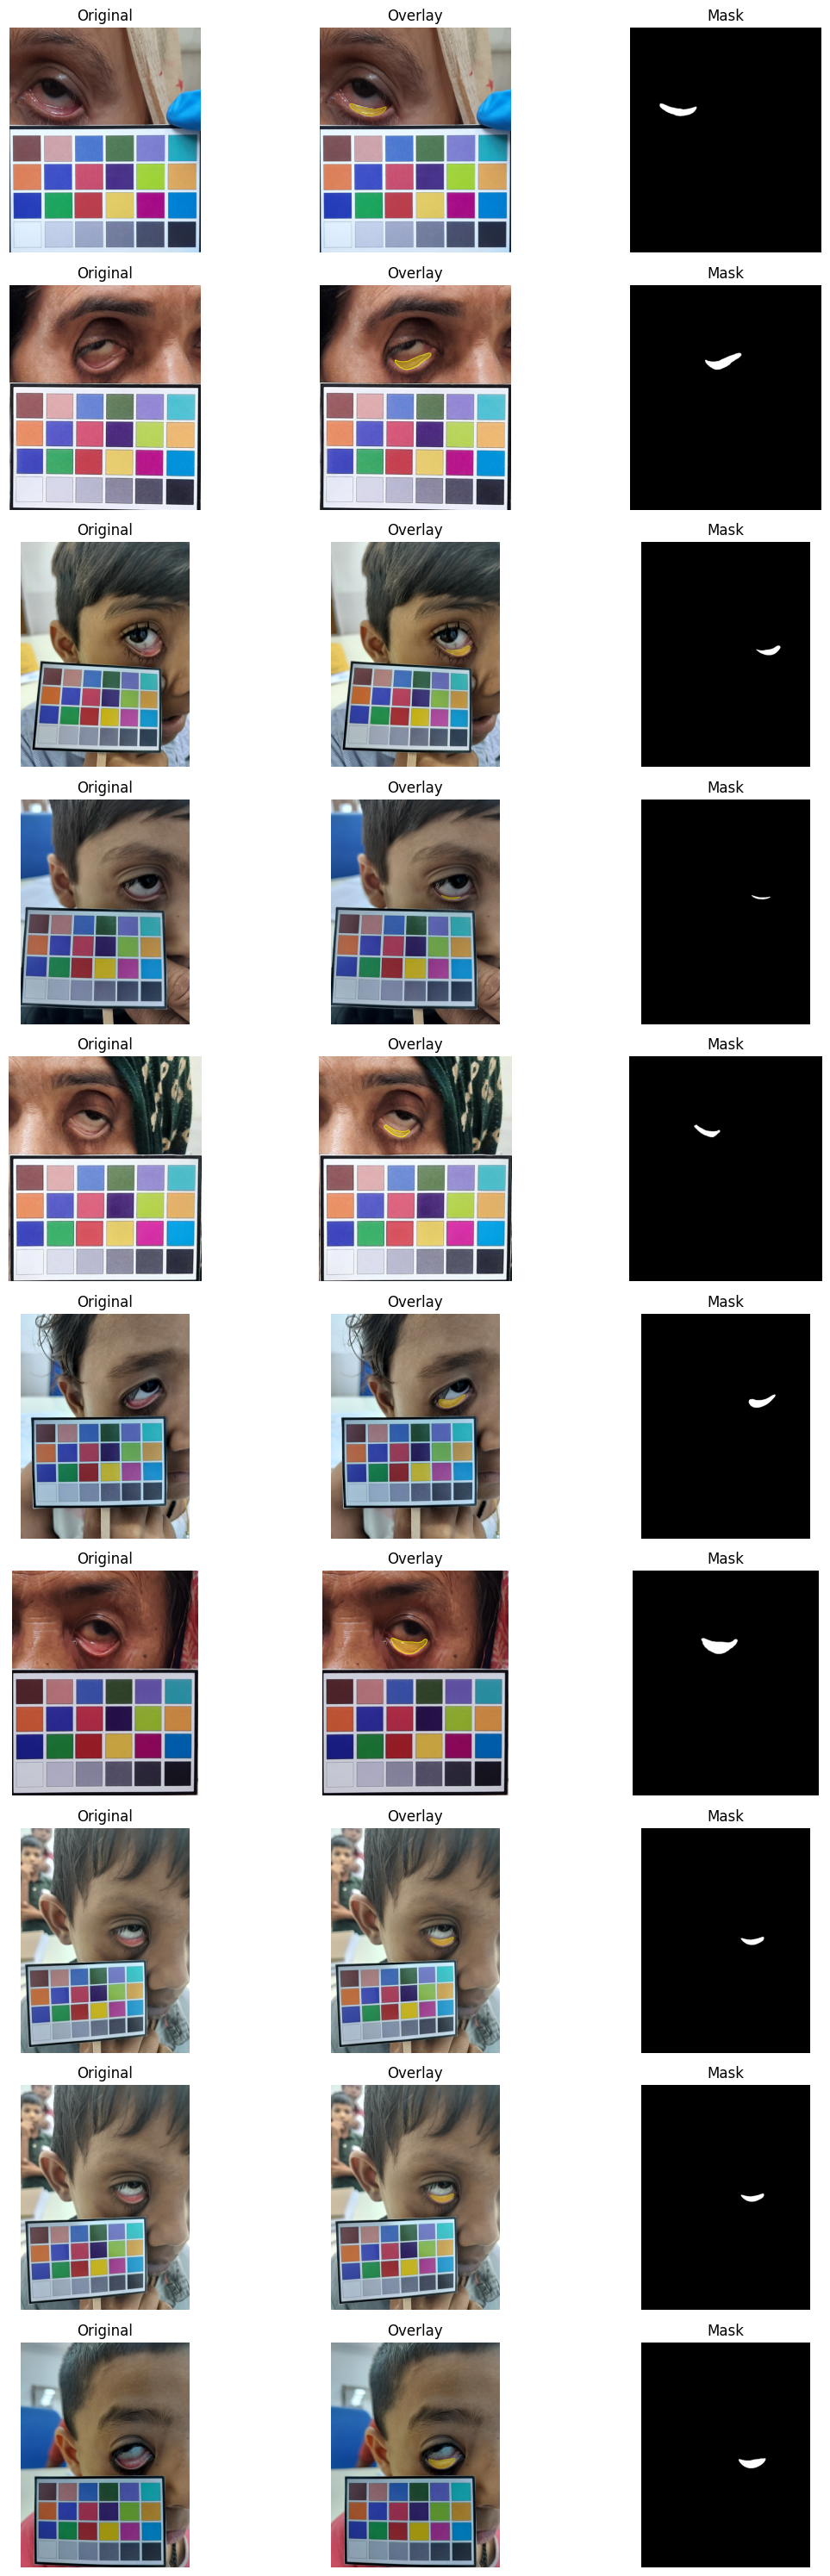

In [2]:
# Masks_overlay
import os
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt

# =========================
# CONFIG
# =========================
GEOJSON_DIR = "/home/khushi/Pixonate/New_Anemia/R_new_anemia/model_outputs/seg_outputs1/Finetune_data/Data/seg_1/seg_1_qu/seggeojsons"
IMAGE_DIR   = "/home/khushi/Pixonate/New_Anemia/R_new_anemia/model_outputs/seg_outputs1/Finetune_data/CV_images"
OUTPUT_DIR  = "/home/khushi/Pixonate/New_Anemia/R_new_anemia/model_outputs/seg_outputs1/Finetune_data/Data/seg_1/seg_1_qu/segmasks_overlay"

MAX_SHOW = 10
ALPHA = 0.35  # transparency
YELLOW = (0, 255, 255)  # BGR light yellow

os.makedirs(OUTPUT_DIR, exist_ok=True)

# =========================
# UTILS
# =========================
def load_geojson(path):
    with open(path) as f:
        return json.load(f)

def create_mask(h, w, geo):
    mask = np.zeros((h, w), dtype=np.uint8)
    for feature in geo.get("features", []):
        geom = feature.get("geometry", {})
        if geom.get("type") != "Polygon":
            continue
        poly = np.array(geom["coordinates"][0], dtype=np.int32)
        cv2.fillPoly(mask, [poly], 255)
    return mask

def overlay_geojson(img, geo):
    overlay = img.copy()
    for feature in geo.get("features", []):
        geom = feature.get("geometry", {})
        if geom.get("type") != "Polygon":
            continue
        poly = np.array(geom["coordinates"][0], dtype=np.int32)
        cv2.fillPoly(overlay, [poly], YELLOW)
        cv2.polylines(img, [poly], True, YELLOW, 2)
    return cv2.addWeighted(overlay, ALPHA, img, 1 - ALPHA, 0)

# =========================
# PROCESS & DISPLAY
# =========================
fig, axes = plt.subplots(MAX_SHOW, 3, figsize=(12, MAX_SHOW * 3))

shown = 0

for name in sorted(os.listdir(GEOJSON_DIR)):
    if shown >= MAX_SHOW:
        break
    if not name.endswith(".geojson"):
        continue

    base = os.path.splitext(name)[0]

    # find image
    img_path = None
    for ext in [".jpg", ".jpeg", ".png"]:
        p = os.path.join(IMAGE_DIR, base + ext)
        if os.path.exists(p):
            img_path = p
            break

    if img_path is None:
        continue

    geo = load_geojson(os.path.join(GEOJSON_DIR, name))
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w = img.shape[:2]
    mask = create_mask(h, w, geo)
    overlay = overlay_geojson(img.copy(), geo)

    # save overlay
    cv2.imwrite(os.path.join(OUTPUT_DIR, base + "_overlay.jpg"), overlay)

    # plot
    axes[shown, 0].imshow(img_rgb)
    axes[shown, 0].set_title("Original")
    axes[shown, 0].axis("off")

    axes[shown, 1].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    axes[shown, 1].set_title("Overlay")
    axes[shown, 1].axis("off")

    axes[shown, 2].imshow(mask, cmap="gray")
    axes[shown, 2].set_title("Mask")
    axes[shown, 2].axis("off")

    shown += 1

plt.tight_layout()
plt.show()


In [5]:
import os
from pathlib import Path

import cv2
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

from ultralytics import YOLO
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2


# =========================
# CONFIG
# =========================
YOLO_MODEL_PATH = "/home/khushi/Pixonate/New_Anemia/R_new_anemia/model_outputs/eye_outputs/Finetune_data/CV_images/cv2_qu/eye_split/Fbest.pt"
SEG_MODEL_PATH  = "/home/khushi/Pixonate/New_Anemia/R_new_anemia/model_outputs/seg_outputs1/Finetune_data/Data/seg_1/seg_1_qu/F_seg_best.pth"

IMAGE_FOLDER   = "/home/khushi/Pixonate/New_Anemia/R_new_anemia/model_outputs/seg_outputs1/Finetune_data/Data/seg_1/seg_1_qu/T"
OUTPUT_FOLDER  = "/home/khushi/Pixonate/New_Anemia/R_new_anemia/model_outputs/seg_outputs1/Finetune_data/Data/seg_1/seg_1_qu/TR"

YOLO_IMG_SIZE = 1024
SEG_IMG_SIZE  = 256
CONF_THRES    = 0.5

os.makedirs(OUTPUT_FOLDER, exist_ok=True)


# =========================
# DEVICE
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# =========================
# LOAD YOLO MODEL
# =========================
yolo_model = YOLO(YOLO_MODEL_PATH)


# =========================
# LOAD SEGMENTATION MODEL
# =========================
seg_model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=3,
    classes=1
)

seg_model.load_state_dict(
    torch.load(SEG_MODEL_PATH, map_location=device)
)
seg_model.to(device)
seg_model.eval()


# =========================
# SEG TRANSFORM (SAME AS TRAINING)
# =========================
seg_transform = A.Compose([
    A.LongestMaxSize(max_size=SEG_IMG_SIZE),
    A.PadIfNeeded(SEG_IMG_SIZE, SEG_IMG_SIZE, border_mode=cv2.BORDER_REFLECT),
    A.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])


# =========================
# HELPER: OVERLAY MASK
# =========================
def overlay_mask(image, mask):
    overlay = image.copy()
    overlay[mask > 0] = (0, 255, 0)
    return cv2.addWeighted(image, 0.7, overlay, 0.3, 0)


# =========================
# INFERENCE LOOP
# =========================
image_paths = sorted(list(Path(IMAGE_FOLDER).glob("*.*")))

for img_path in image_paths:
    print(f"Processing: {img_path.name}")

    # ---- Load original image
    orig_bgr = cv2.imread(str(img_path))
    orig_rgb = cv2.cvtColor(orig_bgr, cv2.COLOR_BGR2RGB)

    # ---- YOLO Eye Detection
    yolo_results = yolo_model.predict(
        source=orig_rgb,
        imgsz=YOLO_IMG_SIZE,
        conf=CONF_THRES,
        device=0 if torch.cuda.is_available() else "cpu",
        verbose=False
    )

    if len(yolo_results[0].boxes) == 0:
        print("⚠️ No eye detected, skipping.")
        continue

    # ---- Take first detected eye
    box = yolo_results[0].boxes.xyxy[0].cpu().numpy().astype(int)
    x1, y1, x2, y2 = box

    eye_crop = orig_rgb[y1:y2, x1:x2]

    if eye_crop.size == 0:
        print("⚠️ Invalid crop, skipping.")
        continue

    # ---- Prepare for segmentation
    aug = seg_transform(image=eye_crop)
    seg_input = aug["image"].unsqueeze(0).to(device)

    # ---- Segmentation inference
    with torch.no_grad():
        pred = seg_model(seg_input)
        pred_mask = torch.sigmoid(pred)[0, 0].cpu().numpy()
        pred_mask = (pred_mask > 0.5).astype(np.uint8)

    # ---- Resize for visualization
    eye_vis = cv2.resize(eye_crop, (SEG_IMG_SIZE, SEG_IMG_SIZE))
    mask_vis = pred_mask * 255
    overlay_vis = overlay_mask(eye_vis, pred_mask)

    # =========================
    # GRID VISUALIZATION
    # =========================
    fig, axs = plt.subplots(1, 4, figsize=(16, 4))

    axs[0].imshow(orig_rgb)
    axs[0].set_title("Original Image")

    axs[1].imshow(eye_vis)
    axs[1].set_title("YOLO Eye Crop")

    axs[2].imshow(mask_vis, cmap="gray")
    axs[2].set_title("Predicted Mask")

    axs[3].imshow(overlay_vis)
    axs[3].set_title("Overlay")

    for ax in axs:
        ax.axis("off")

    save_path = os.path.join(
        OUTPUT_FOLDER, f"{img_path.stem}_result.png"
    )
    plt.tight_layout()
    plt.savefig(save_path, dpi=200)
    plt.close()

print("✅ Inference completed. Results saved.")


Processing: 1.13.5.jpg
Processing: 100.10.1.jpg
⚠️ No eye detected, skipping.
Processing: 101.10.1.jpg
⚠️ No eye detected, skipping.
Processing: 102.13.9.jpg
Processing: 103.11.9.jpg
⚠️ No eye detected, skipping.
Processing: 105.15.8.jpg
⚠️ No eye detected, skipping.
Processing: 107.14.5.jpg
Processing: 19.9.3.jpg
⚠️ No eye detected, skipping.
✅ Inference completed. Results saved.
